In [2]:
import kagglehub
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")


In [ ]:
import pathlib
data_dir = pathlib.Path(path) / "Rice_Image_Dataset"
print(data_dir)


C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset


In [5]:
for item in data_dir.iterdir():
    print(item)

C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Arborio
C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Basmati
C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Ipsala
C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Jasmine
C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Karacadag
C:\Users\HP\.cache\kagglehub\datasets\muratkokludataset\rice-image-dataset\versions\1\Rice_Image_Dataset\Rice_Citation_Request.txt


In [6]:
arborio  = list(data_dir.glob('Arborio/*'))[:600]
basmati  = list(data_dir.glob('Basmati/*'))[:600]
ipsala   = list(data_dir.glob('Ipsala/*'))[:600]
jasmine  = list(data_dir.glob('Jasmine/*'))[:600]
karacadag = list(data_dir.glob('Karacadag/*'))[:600]

In [ ]:

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.image as img
from PIL import Image
import cv2
import os
import numpy as np
import pathlib
print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [14]:
df_images = {
    'arborio': arborio,
    'basmati': basmati,
    'ipsala': ipsala,
    'jasmine': jasmine,
    'karacadag': karacadag
}

In [ ]:
img = cv2.imread(str(df_images['arborio'][0]))  
img.shape  

(250, 250, 3)

In [ ]:
df_images = {
    'arborio'  : arborio,
    'basmati'  : basmati,
    'ipsala'   : ipsala,
    'jasmine'  : jasmine,
    'karacadag': karacadag
}

df_labels = {
    'arborio'  : 0,
    'basmati'  : 1,
    'ipsala'   : 2,
    'jasmine'  : 3,
    'karacadag': 4
}

In [ ]:
X, y = [], [] 
for label, images in df_images.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (224, 224)) 
        X.append(resized_img)
        y.append(df_labels[label])

In [ ]:
X = np.array(X)
X = X / 255
y = np.array(y)

In [ ]:
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val)

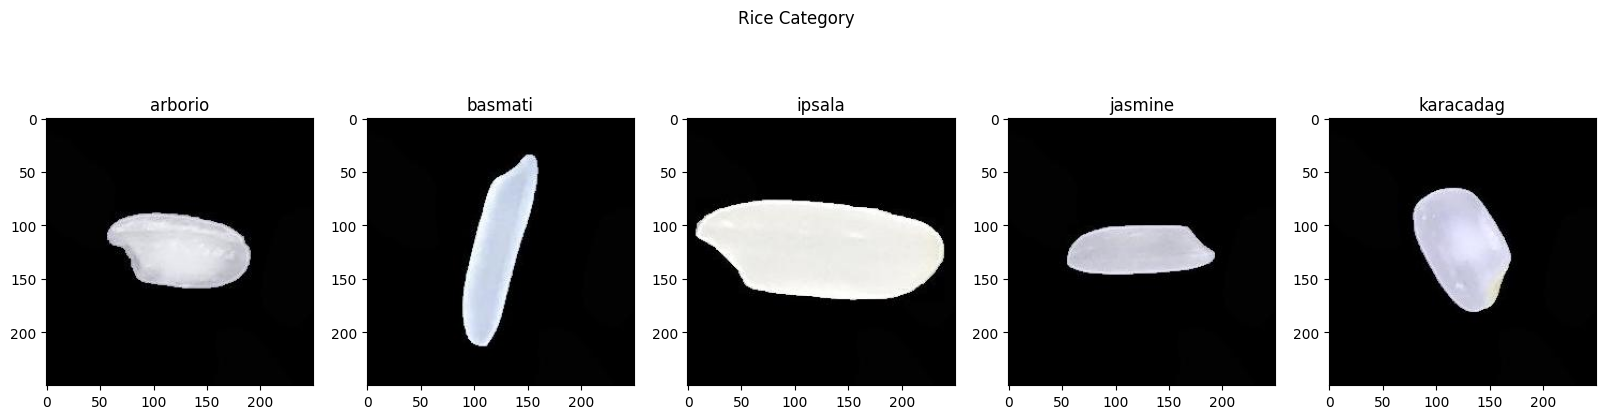

In [ ]:
fig, ax = plt.subplots(ncols=5, figsize=(20, 5))
fig.suptitle('Rice Category')
arborio_image   = plt.imread(str(arborio[0]))
basmati_image   = plt.imread(str(basmati[0]))
ipsala_image    = plt.imread(str(ipsala[0]))
jasmine_image   = plt.imread(str(jasmine[0]))
karacadag_image = plt.imread(str(karacadag[0]))
ax[0].set_title('arborio')
ax[1].set_title('basmati')
ax[2].set_title('ipsala')
ax[3].set_title('jasmine')
ax[4].set_title('karacadag')
ax[0].imshow(arborio_image)
ax[1].imshow(basmati_image)
ax[2].imshow(ipsala_image)
ax[3].imshow(jasmine_image)
ax[4].imshow(karacadag_image)

plt.show()

In [ ]:

mobile_net = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  
    weights='imagenet'
)

mobile_net.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
num_label = 5  

model = keras.Sequential([
    mobile_net,
    keras.layers.GlobalAveragePooling2D(), 
    keras.layers.Dense(num_label, activation='softmax')
])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['acc']
)

In [27]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 39s 443ms/step - acc: 0.8596 - loss: 0.5361 - val_acc: 0.9521 - val_loss: 0.2234
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 772ms/step - acc: 0.9796 - loss: 0.1436 - val_acc: 0.9521 - val_loss: 0.1538
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 33s 462ms/step - acc: 0.9818 - loss: 0.0962 - val_acc: 0.9681 - val_loss: 0.1308
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 408ms/step - acc: 0.9871 - loss: 0.0766 - val_acc: 0.9628 - val_loss: 0.1142
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 414ms/step - acc: 0.9871 - loss: 0.0635 - val_acc: 0.9734 - val_loss: 0.1041
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 426ms/step - acc: 0.9884 - loss: 0.0560 - val_acc: 0.9787 - val_loss: 0.0980
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 414ms/step - acc: 0.9907 - loss: 0.0470 - val_acc: 0.9521 - val_loss: 0.1279
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 424ms/step - acc: 0.9898 - loss: 0.0439 - val_acc: 0.9787 - val_loss: 0.0846
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 403ms/

In [29]:
from plotly.offline import iplot, init_notebook_mode
import plotly.express as px
import pandas as pd

init_notebook_mode(connected=True)

acc = pd.DataFrame({'train': history.history['acc'], 'val': history.history['val_acc']})

fig = px.line(acc, x=acc.index, y=acc.columns[0::], title='Training and Evaluation Accuracy every Epoch')
fig.show()

In [30]:
loss = pd.DataFrame({'train': history.history['loss'], 'val': history.history['val_loss']})

fig = px.line(loss, x=loss.index, y=loss.columns[0::], title='Training and Evaluation Loss every Epoch')
fig.show()

In [31]:
a1 = cv2.imread(str(basmati[10]))
a1 = cv2.resize(a1, (224, 224))
a1 = np.array(a1)
a1 = a1 / 255
a1 = np.expand_dims(a1, 0)
pred = model.predict(a1)
pred = pred.argmax()
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


np.int64(1)

In [32]:
for i, j in df_labels.items():
    if pred == j:
        print(i)

basmati


In [33]:
model.save("rice.h5")